#Deep Dive into LangChain: Architecture, Components, and Building LLM Applications

##1. Introduction to LangChain
With the rapid advancement of Large Language Models (LLMs) such as GPT and open-source transformer models, building intelligent applications has become more accessible. However, directly using LLMs in applications often leads to several challenges such as lack of structure, difficulty in managing prompts, and inability to integrate external tools effectively.

LangChain is an open-source framework designed to simplify the development of applications powered by LLMs. It provides a structured and modular approach to building AI systems by combining multiple components such as prompts, models, memory, and tools into a unified pipeline.

###What is LangChain?

LangChain is a framework that enables developers to build applications using LLMs by chaining together different components. Instead of writing standalone prompts, developers can design complete workflows where inputs pass through multiple stages before generating output.

In simple terms, LangChain helps in:
- Connecting LLMs with external data sources
- Creating multi-step reasoning pipelines
- Managing prompt templates efficiently
- Building scalable AI systems

###Why is LangChain Important?

In modern AI applications, a single prompt is often not enough. Real-world systems require:
- Multi-step reasoning (e.g., analyze → process → respond)
- Integration with APIs, databases, and tools
- Context retention (memory)

LangChain provides a solution by:
- Allowing chaining of multiple operations
- Supporting modular architecture
- Enabling integration with tools like search engines, databases, and APIs

This makes it highly useful for building production-level AI systems.

###Problems Solved by LangChain

LangChain addresses several key limitations of directly using LLMs:

####1. Prompt Management
Managing prompts manually becomes difficult as applications grow. LangChain introduces PromptTemplate for reusable and dynamic prompts.

####2. Workflow Orchestration
Complex applications require multiple steps. LangChain enables chaining of operations, allowing structured workflows.

####3. Tool Integration
LLMs alone cannot fetch real-time data. LangChain allows integration with external tools such as APIs, search engines, and databases.

####4. Memory Handling
LLMs do not remember past interactions by default. LangChain provides memory modules to maintain conversational context.

— -

In this blog, we will explore the core components of LangChain, understand its architecture, and implement practical examples to build real-world LLM-powered applications.

##2. Core Components of LangChain
LangChain is built using modular components that work together to create powerful LLM-based applications. Each component serves a specific role in the pipeline.

###1. LLMs and Chat Models
LLMs are the core of LangChain. They generate responses based on input prompts.

Why it exists:
LLMs are responsible for reasoning, text generation, and answering queries.

Code Example

In [1]:
from transformers import pipeline

model = pipeline("text-generation", model="gpt2")
response = model("Explain machine learning", max_new_tokens=50)

print(response[0]["generated_text"])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Passing `generation_config` together with generation-related arguments=({'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=50) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Explain machine learning and how to solve these problems with a neural network.

What are the benefits of neural networks?

These networks are built from a large number of lessons to help you solve problems and help you in the future.

What are the


###2. Prompts and Prompt Templates
Prompts define how input is given to the LLM. PromptTemplate allows dynamic and reusable prompts.

####Why it exists:

#####Avoid hardcoding prompts
#####Improve flexibility
#####Enable dynamic input
#####Code Example

In [2]:
from langchain_core.prompts import PromptTemplate

template = "Explain {topic} in simple terms"

prompt = PromptTemplate(
    input_variables=["topic"],
    template=template
)

print(prompt.format(topic="AI"))

Explain AI in simple terms


###3. Chains
Chains combine multiple steps into a pipeline.

####Why it exists:

#####Automate multi-step workflows
#####Improve modularity
#####Code Example

In [3]:
# Simple chain concept
def simple_chain(input_text):
    return input_text.upper()

print(simple_chain("hello"))

HELLO


###4. Memory
Memory allows the system to remember previous interactions.

####Why it exists:

Maintain context in conversations
Improve user experience
#####Example

Chatbots remembering previous messages.

###5. Agents
Agents make decisions dynamically and choose actions.

####Why it exists:

Enable reasoning
Allow tool selection
####Example:
Agent deciding whether to search or calculate.

###6. Tools
Tools are external functionalities like APIs.

####Why it exists:

Extend LLM capability
Fetch real-time data
####Examples:

Calculator
Web search
###7. Document Loaders
Used to load external data such as PDFs or text files.

####Why it exists:

Provide knowledge to LLM
####Example:
Loading a PDF for question answering.

###8. Vector Stores
Vector stores store embeddings for similarity search.

####Why it exists:

Enable semantic search
Power retrieval-based systems
####Example:
Finding similar documents using embeddings.

##3. Architecture Explanation
LangChain follows a modular pipeline architecture where different components work together to process user input and generate output.

The flow of a typical LangChain system is:

###User Input → Prompt → LLM → Chain → Tool/Agent → Output

###Step-by-Step Explanation
####1. User Input
The process starts when a user provides input, such as a question or query.

####2. Prompt
The input is formatted using a PromptTemplate to structure it properly for the LLM.

####3. LLM
The formatted prompt is passed to a Large Language Model, which generates a response.

####4. Chain
Chains manage multi-step workflows by combining multiple operations together.

####5. Tool / Agent
If required, the system interacts with external tools (APIs, databases) using agents.

####6. Output
The final processed result is returned to the user.

This architecture allows LangChain to handle complex tasks such as multi-step reasoning, tool usage, and context-aware responses.


In [6]:
from google.colab import files
uploaded = files.upload()

Saving LangChain Architecture.png to LangChain Architecture.png


(np.float64(-0.5), np.float64(1535.5), np.float64(1023.5), np.float64(-0.5))

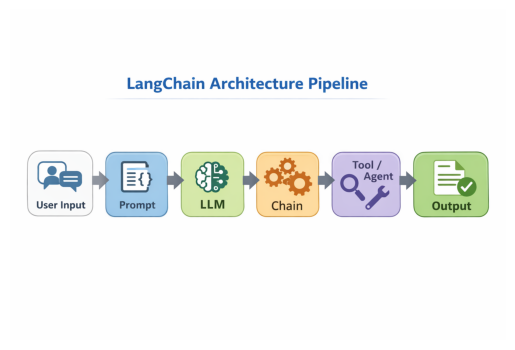

In [8]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("LangChain Architecture.png")

plt.imshow(img)
plt.axis('off')

##4. Hands-on Code Examples
In this section, we implement practical examples using LangChain to understand how different components work together.

###1. Basic LLM Call

This example shows how to generate text using a language model.

In [9]:
from transformers import pipeline
model = pipeline("text-generation", model="gpt2")
response = model("Explain artificial intelligence", max_new_tokens=50)
print(response[0]["generated_text"])

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=50) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Explain artificial intelligence and artificial intelligence to improve life.

The United Nations said last month that it hoped to have a goal of "farming the world with intelligent life support systems to enable developing nations to take steps to ensure the security of their own citizens."



###2. PromptTemplate Usage

PromptTemplate allows dynamic input insertion.

In [10]:
from langchain_core.prompts import PromptTemplate

template = "Explain {topic} in simple terms"

prompt = PromptTemplate(
    input_variables=["topic"],
    template=template
)

print(prompt.format(topic="Machine Learning"))

Explain Machine Learning in simple terms


###3. Simple Chain Example

Chains allow combining multiple steps.

In [11]:
def simple_chain(text):
    return text.lower()

print(simple_chain("HELLO LANGCHAIN"))

hello langchain


###4. Memory Example

Memory helps retain context.

####Example:
A chatbot remembering previous messages in a conversation.

In [12]:
conversation_history = []

def chat(user_input):
    conversation_history.append(user_input)
    return f"Previous messages: {conversation_history}"

print(chat("Hello"))
print(chat("How are you?"))

Previous messages: ['Hello']
Previous messages: ['Hello', 'How are you?']


###5. Agent with Tool Example

Agents can use tools dynamically.

####Example:
A simple calculator tool.

In [13]:
def calculator(a, b):
    return a + b

print("Result:", calculator(5, 3))

Result: 8


##5. Real-World Use Cases
LangChain is widely used in building real-world AI applications that require reasoning, context handling, and integration with external tools.

###1. AI Resume Screening System

####Problem:
Recruiters need to evaluate large numbers of resumes efficiently.

####Solution using LangChain:
LangChain can extract skills from resumes, match them with job descriptions, and assign scores with explanations.

####Components used:
- PromptTemplate (for structured prompts)
- Chains (for multi-step processing)
- Tools (for data handling)

— -

###2. Chatbots with Memory

####Problem:
Basic chatbots cannot remember previous conversations.

####Solution using LangChain:
LangChain memory modules allow chatbots to retain conversation history and provide context-aware responses.

####Components used:
- Memory
- LLMs
- Chains

— -

###3. Document Question Answering System

####Problem:
Users need answers from large documents (PDFs, reports).

####Solution using LangChain:
LangChain loads documents, converts them into embeddings, and retrieves relevant information for answering queries.

####Components used:
- Document Loaders
- Vector Stores
- Retrieval Chains

— -

These use cases demonstrate how LangChain enables building intelligent, scalable, and production-ready AI systems.

##6. Advantages and Limitations
LangChain provides powerful capabilities for building LLM-based applications, but like any framework, it has both advantages and limitations.

###Advantages

####1. Modularity
LangChain is highly modular. Developers can combine different components such as prompts, memory, and tools to build flexible systems.

####2. Rapid Prototyping
It allows quick development of AI applications without building everything from scratch.

####3. Tool Integration
LangChain supports integration with external tools such as APIs, databases, and search engines, enabling real-world applications.

####4. Multi-Step Reasoning
Chains allow multi-step workflows, making it possible to perform complex tasks beyond simple prompt-response systems.

####5. Memory Support
LangChain provides memory modules to retain context, which is essential for conversational applications.

— -

###Limitations

####1. Latency
Multi-step chains and tool calls can increase response time.

####2. Debugging Complexity
As workflows become complex, debugging chains and agents can be difficult.

####3. Cost
Using APIs (like OpenAI) can become expensive for large-scale applications.

####4. Overhead
For simple tasks, LangChain may introduce unnecessary complexity compared to direct LLM usage.

— -

###When NOT to Use LangChain

- For simple one-step tasks (basic prompt-response)
- When low latency is critical
- When application does not require chaining or tool integration

— -

Understanding these trade-offs helps in deciding when and how to use LangChain effectively.

##7. Conclusion
In this blog, we explored LangChain as a powerful framework for building LLM-based applications. We started with understanding its purpose and importance in the modern AI ecosystem, followed by a detailed discussion of its core components such as LLMs, prompt templates, chains, memory, agents, tools, and vector stores.


We also examined how LangChain enables modular and scalable architectures, making it easier to design complex workflows involving multiple steps and external integrations. Through hands-on examples, we saw how different components can be implemented in Python to build functional AI systems.


Additionally, we explored real-world use cases such as resume screening systems, conversational chatbots, and document question-answering systems, which demonstrate the practical value of LangChain in real applications.


While LangChain offers several advantages such as modularity and rapid development, it also comes with challenges like latency and debugging complexity. Understanding these trade-offs is important when deciding its usage.


###Future Scope:

The future of LangChain lies in more advanced frameworks like LangGraph and multi-agent systems, which allow even more complex and intelligent workflows. As LLM applications continue to evolve, frameworks like LangChain will play a crucial role in building scalable and production-ready AI solutions.


Overall, LangChain provides a strong foundation for designing modern AI applications and is an essential tool for developers working in the field of Generative AI.